In [35]:
#import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [36]:
######################## Define the text size of each plot globally ###########
SMALL_SIZE = 10
BIGGER_SIZE = 10

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

plt.rcParams["font.family"] = "Arial"
######################## Define the text size of each plot globally ###########

In [37]:
df = pd.read_excel(r'..\\data\10_summary.xlsx')
df = df.drop(index=7)  # Drops the row with index 7
df = df.reset_index(drop=True)

In [38]:
df

,Parameter,Unit,P1,P2,P3,P4,P5,P6,ML
0,E50ref,kPa,20541.0000,18467.166200,25000.00,23200.000000,20000.0000,16000.00,20972.4960
1,Eoedref,kPa,21000.0000,21138.749577,25000.00,31800.000000,17500.0000,24300.00,21656.6760
2,Eurref,kPa,82024.0000,63416.248731,75000.00,78900.000000,70000.0000,90000.00,107278.6560
3,φ',°,37.0000,36.900000,36.70,37.000000,36.0000,37.00,37.4230
4,c'ref,kPa,0.0000,0.000000,1.00,0.000000,2.0000,0.00,0.0000
5,ψ',°,9.0000,8.600000,9.00,8.000000,10.0000,7.00,7.5940
6,m,-,0.5000,0.700000,0.60,0.720000,0.5000,0.90,0.6770
7,Rf,-,0.9000,0.900000,0.92,0.900000,0.9000,0.90,0.9520
8,K0NC,-,0.3982,0.400000,0.40,0.398185,0.4122,0.40,0.4080
9,pref,kPa,100.0000,100.000000,100.00,100.000000,100.0000,100.00,100.0000


In [39]:
ML = pd.DataFrame(df.iloc[:,-1])

In [40]:
ML

,ML
0,20972.4960
1,21656.6760
2,107278.6560
3,37.4230
4,0.0000
5,7.5940
6,0.6770
7,0.9520
8,0.4080
9,100.0000


In [41]:
df = df.iloc[:, 0:8]

In [42]:
df

,Parameter,Unit,P1,P2,P3,P4,P5,P6
0,E50ref,kPa,20541.0000,18467.166200,25000.00,23200.000000,20000.0000,16000.00
1,Eoedref,kPa,21000.0000,21138.749577,25000.00,31800.000000,17500.0000,24300.00
2,Eurref,kPa,82024.0000,63416.248731,75000.00,78900.000000,70000.0000,90000.00
3,φ',°,37.0000,36.900000,36.70,37.000000,36.0000,37.00
4,c'ref,kPa,0.0000,0.000000,1.00,0.000000,2.0000,0.00
5,ψ',°,9.0000,8.600000,9.00,8.000000,10.0000,7.00
6,m,-,0.5000,0.700000,0.60,0.720000,0.5000,0.90
7,Rf,-,0.9000,0.900000,0.92,0.900000,0.9000,0.90
8,K0NC,-,0.3982,0.400000,0.40,0.398185,0.4122,0.40
9,pref,kPa,100.0000,100.000000,100.00,100.000000,100.0000,100.00


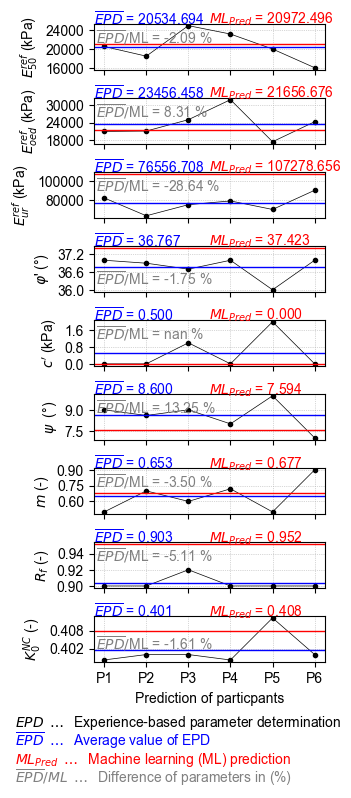

In [43]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np

# Assuming df and ML are already defined

# Define plot structure
nrows = 10
ncols = 1
cm = 1/2.54  # centimeters in inches
figsize = (8.4*cm, 20*cm)

# Create subplots for each parameter
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharex=True)
parameters = df['Parameter']

parameters_plot = ['$E_{50}^{ref}$ (kPa)', '$E_{oed}^{ref}$ (kPa)', '$E_{ur}^{ref}$ (kPa)', 
                      "$\\varphi$' (°)", "$c'$ (kPa)",'$\psi$  (°)',
                      '${m}$ (-)',
                      '${R_f}$ (-)', '$K_0^{NC}$ (-)','$p^{ref}$  (kPa)', 'Time (h)']

colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

# Columns to include in the average calculation
average_columns = df.columns[2:]

# Flatten the 2D array of axes to iterate easily
axs = axs.flatten()

#x_value = [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.1]
x_value = [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.1]
y_value = [0.9, 0.9, 0.9, 0.5, 0.9, 0.9, 0.9, 0.9, 0.6, 0.9, 0.9]

# Plot each parameter in a separate subplot
for i, ax in enumerate(axs[:len(parameters)]):
    if i < len(parameters)-2:  # Plot everything except the second-to-last plot
        ax.plot(df.columns[2:], df.iloc[i, 2:], label=parameters[i], color='k', marker='o', markersize=3, lw = 0.5)

        average_value = np.average(df[average_columns].iloc[i])
        ax.axhline(average_value, color='b', linestyle='-', label='Average', alpha = 1, lw = 1.0)
        ax.text(0.00, 1.3, s = '$\\overline{EPD}$'+f' = {average_value:.3f}', color = 'b', transform=ax.transAxes, ha='left', va='top', alpha = 1)

        ax.axhline(ML.iloc[i, 0], color='r', linestyle='-', label='ML', lw = 1.0)
        ax.text(0.5, 1.28, s = '$ML_{Pred}$'+f' = {ML.iloc[i, 0]:.3f}', color = 'r', transform=ax.transAxes, ha='left', va='top',)

        ax.text(x_value[i], y_value[i], s = '$\\overline{EPD} / $ML'+f' = {np.average(((df.iloc[i, 2:] / ML.iloc[i, 0]) * 100 - 100)):.2f} %', color = 'gray', transform=ax.transAxes, ha='left', va='top',)

    # elif i == len(parameters)-2:  # Plot the last one
    #     i = i + 1
    #     ax.bar(df.columns[2:], df.iloc[i, 2:], label=parameters[i], color='grey', alpha=0.6)

    #     average_value = np.average(df[average_columns].iloc[i])
    #     ax.axhline(average_value, color='b', linestyle='--', label='Average', alpha = 0.5, lw = 1.0)
    #     ax.text(0.02, 1.3, s = '$\\overline{EPD}$'+f' = {average_value:.4f}', color = 'b', transform=ax.transAxes, ha='left', va='top', alpha = 0.5)

    #     ax.axhline(ML.iloc[i, 0], color='r', linestyle='--', label='ML$_{Pred}$', lw = 1.0)
    #     ax.text(0.5, 1.28, s = '$ML_{Pred}$'+f' = {ML.iloc[i, 0]:.4f}', color = 'r', transform=ax.transAxes, ha='left', va='top',)

    #     ax.text(x_value[i], y_value[i], s = 'Speed-up ratio $\\overline{EPD} / ML$'+f' = {(np.average(df.iloc[i, 2:]) / ML.iloc[i, 0]):.0f}', color = 'k', transform=ax.transAxes, ha='left', va='top',)

    ax.set_ylabel(parameters_plot[i])
    ax.tick_params(axis='y')
    ax.grid(lw = 0.5, linestyle = 'dotted')
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))  # Ensure at least 3 y-ticks

# Re-enable the x-axis for the third-to-last plot
axs[8].tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
axs[9].tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)

axs[-2].set_xlabel('Prediction of particpants')

# Hide any unused subplots and set the position for text insertion
for j in range(len(parameters), len(axs)):
    fig.delaxes(axs[j])

# Remove the second-to-last subplot and add the text box
fig.delaxes(axs[len(parameters)-2])
text_ax = fig.add_subplot(nrows, ncols, len(parameters)-1)

# texts = ["$EPD \;\;\; \;\;\; \; \, \dots \;$ Experience-based parameter determination",
# "$\\overline{EPD} \; \; \;\; \; \; \; \, \dots \;$ Average value of EPD",
# "$ML_{Pred} \; \; \; \: \dots \;$ Machine learning (ML) prediction",
# "$\\overline{EPD}/ML \; \dots \;$ Difference of parameters in (%)"]

texts = ["$EPD \; \dots \;$ Experience-based parameter determination",
"$\\overline{EPD}  \; \dots \;$ Average value of EPD",
"$ML_{Pred} \; \dots \;$ Machine learning (ML) prediction",
"$\\overline{EPD}/ML \; \dots \;$ Difference of parameters in (%)"
]
y = -0.6
colors = ['black', 'blue', 'r', 'gray']
alphas = [1,1,1,1]
for text,color,alpha in zip(texts, colors, alphas):
    text_ax.text(-0.34, 0.9+y, text, va='center', ha='left', color = color, alpha = alpha)
    y = y - 0.4

# texts = ["$ML_{Pred} \; \; \; \: \dots \;$ Machine learning (ML) prediction",
# "$\\overline{EPD}/ML \; \dots \;$ Difference of parameters in (%)"]
# y = -1.6
# colors = ['r', 'orange']
# alphas = [1,1,1,1]
# for text,color,alpha in zip(texts, colors, alphas):
#     text_ax.text(-0.15, 0.9+y, text, va='center', ha='left', color = color, alpha = alpha)
#     y = y - 0.4

text_ax.axis('off')

# Set the x-axis label for the bottom row
for ax in axs[-ncols:]:
    ax.set_xlabel('Predictions')



# Adjust layout
plt.subplots_adjust(left=0.25, right=0.95, bottom=0.07, top=0.975, wspace=0.35, hspace=0.6)
plt.savefig(r"../graphics/"+"RealData01_analysis_RealTest_Karlsruhe_200kPa_EPD.png", dpi=1000)


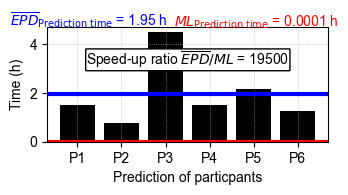

In [44]:
# Define plot structure
nrows = 1
ncols = 1
cm = 1/2.54  # centimeters in inches
figsize = (8.4*cm, 4.5*cm)

# Create subplots for each parameter
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharex=True)

i = i + 1
axs.bar(df.columns[2:], df.iloc[i, 2:], label=parameters[i], color='k', alpha=1)

average_value = np.average(df[average_columns].iloc[i])
axs.axhline(average_value, color='b', linestyle='-', label='Average', alpha = 1, lw = 3.0)
axs.text(-0.13, 1.145, s = '$\\overline{EPD}_{\\text{Prediction time}}$'+f' = {average_value:.2f} h', color = 'b', transform=axs.transAxes, ha='left', va='top', alpha = 1)

axs.axhline(ML.iloc[i, 0], color='r', linestyle='-', label='ML$_{Pred}$', lw = 3.0)
axs.text(0.45, 1.115, s = '$ML_{\\text{Prediction time}}$'+f' = {ML.iloc[i, 0]:.4f} h', color = 'r', transform=axs.transAxes, ha='left', va='top',)

# Update this line to include the desired formatting
axs.text(x_value[i]+0.04, y_value[i]-0.1, s = 'Speed-up ratio $\\overline{EPD} / ML$'+f' = {np.round((np.average(df.iloc[i, 2:]) / ML.iloc[i, 0]),-2):.0f}', 
            color='black', transform=axs.transAxes, ha='left', va='top',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.05'))


axs.set_ylabel(parameters_plot[i])
axs.tick_params(axis='y')
axs.grid(lw = 0.5, linestyle = 'dotted')
axs.yaxis.set_major_locator(MaxNLocator(nbins=3))  # Ensure at least 3 y-ticks

axs.set_xlabel('Prediction of particpants')
axs.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)

# Adjust layout
plt.subplots_adjust(left=0.12, right=0.97, bottom=0.25, top=0.9, wspace=0.35, hspace=0.1)
plt.savefig(r"../graphics/"+"RealData01_analysis_RealTest_Karlsruhe_200kPa_EPD_time.png", dpi=1000)


In [45]:
# input_column = ['E50ref', 'Eoedref', 'Eurref', 
#                 'phi','cref', 'psi', 
#                 'm', 'nu', 
#                 'Rf', 'K0NC', 'pref']

# with open(f'..\\data\pred_analysis_realTest_01_analysis_RealTest_Karlsruhe_200kPa_EPD.txt', 'w', encoding='utf-8') as file:
#     for i in range(len(input_column)):
#         file.write(f"{input_column[i]}: \t {np.average(df.iloc[i,2:]):.3f}\n")